## Dependencies

$\text{Generative model}\\[6pt]
s:~\Psi_t = \Psi_{t-1} + \omega \cdot dt, \quad \omega = \dfrac{2 \pi}{24}\\[5pt]
m:~m_t = I_t + \sigma \cdot \sqrt{I_t} \cdot \eta_t\,, \quad where~~I_t=\max[\cos{\Psi_t}, 0]\\[5pt]
$

In [2]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from helper import sigmoid, hill, sm_simulation, phase2sun, SCN_entrain, plot_dynamics, run_1D_sweep, plotting_1D_sweep, run_2D_sweep, plotting_2D_sweep, plotting_2D_sweep_spatial, load_pickles, print_sweep_tree
from helper import run_1D_ensemble, plotting_1D_ensemble, plot_inspection_grid, plot_unwrapped_phase_walk, plot_phase_walk

## Main

In [3]:
base_config = {
    "N": 100,
    "D": 10,
    "lam": 0.1,
    "gamma": 0.0,
    "mean_period": 23.5,
    "std_period": 0.0,
    "W_prob": 0.2,
    "W_mu": 0.2,
    "W_std": 0,
    "sweep": False,
    "std_phase_noise": 0.05, # 1hr deviation after 24hr
    "std_m_noise": 0.0,
    "dt": 0.1,
    "fastmath": False   #we use strictmath by default
}

$\texttt{- default serious runs:        fastmath=False}\\
\texttt{- huge exploratory scans:      fastmath=True}\\
\texttt{- final / trusted results:     fastmath=False}$

network period: 23.984595057538403
====== SCN TRACKING BENCHMARKS ======
1. Raw amplitude             : 0.5983
2. R_phase                   : 1.0000  (Ideal: 1.0  -> zero spread)
3. Drift Rate                : 0.0154 hr/Day (Ideal: 0.0  -> zero deviation)
4. Circular RMSE             : 2.8509  hr (Ideal: 0.0 -> no wobbling)
5. SCV                       : 0.0191  (Ideal: 0.0 -> low inter-cycle variance)
6. entrainment ratio         : 1.0373  (Ideal: 1.0 -> cycle attendance rate )


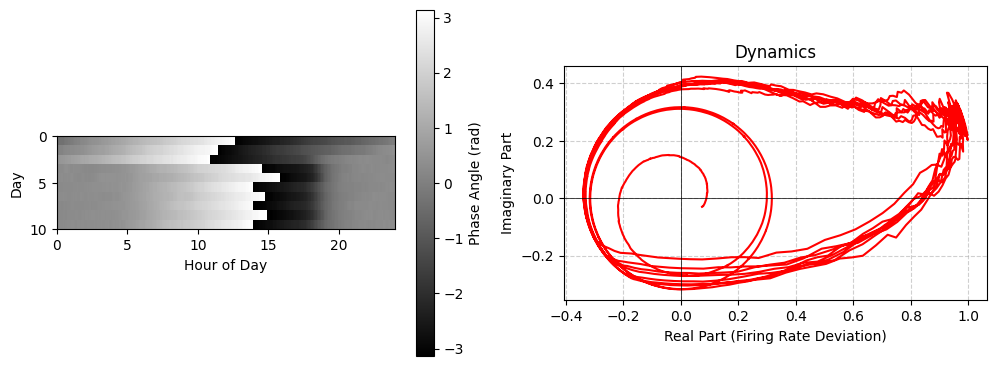

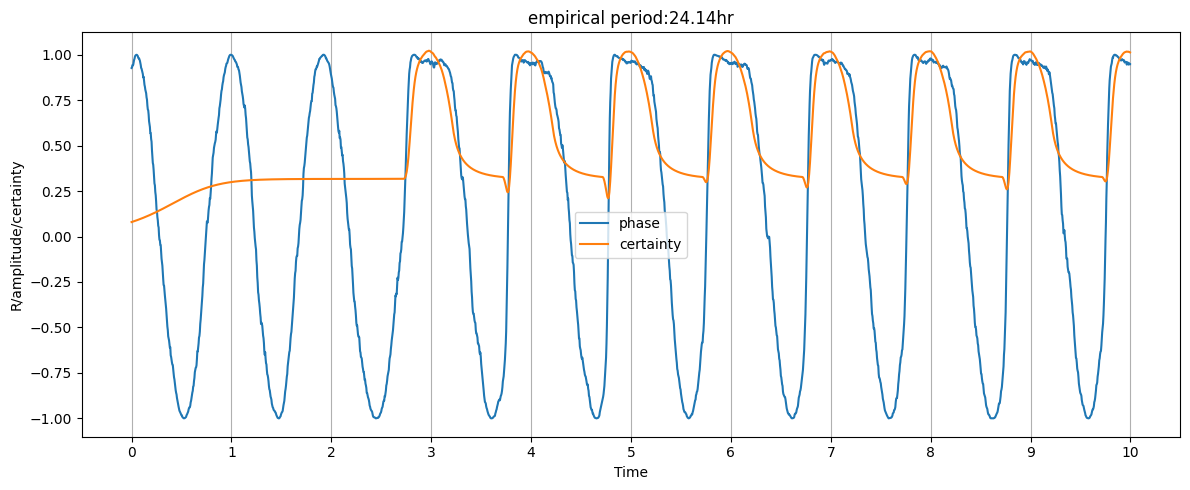

In [87]:
results = SCN_entrain(**{**base_config, "N": 1})
plot_dynamics(results);

### 1D Sweep

--- Simulating Sample 1/10 [NEW] ---


--- Simulating Sample 2/10 [NEW] ---


--- Simulating Sample 3/10 [NEW] ---


--- Simulating Sample 4/10 [NEW] ---


--- Simulating Sample 5/10 [NEW] ---


...

--- Simulating Sample 7/10 [NEW] ---


--- Simulating Sample 8/10 [NEW] ---


--- Simulating Sample 9/10 [NEW] ---


--- Simulating Sample 10/10 [NEW] ---



 ENSEMBLE COMPLETE. Macroscopic state secured in output data/1D ensemble/ensembles/ENS_1D_std_period_e016ba3f.pkl
========= CONFIGURATION =========
{'N': 100,
 'D': 10,
 'lam': 0.1,
 'gamma': 0.0,
 'mean_period': 23.5,
 'W_prob': 0.2,
 'W_mu': 0.05,
 'W_std': 0,
 'sweep': True,
 'std_phase_noise': 0.05,
 'std_m_noise': 0.0,
 'dt': 0.1,
 'fastmath': False}
std_period: (0.000, 7.000, 0.5)
sample size: 10



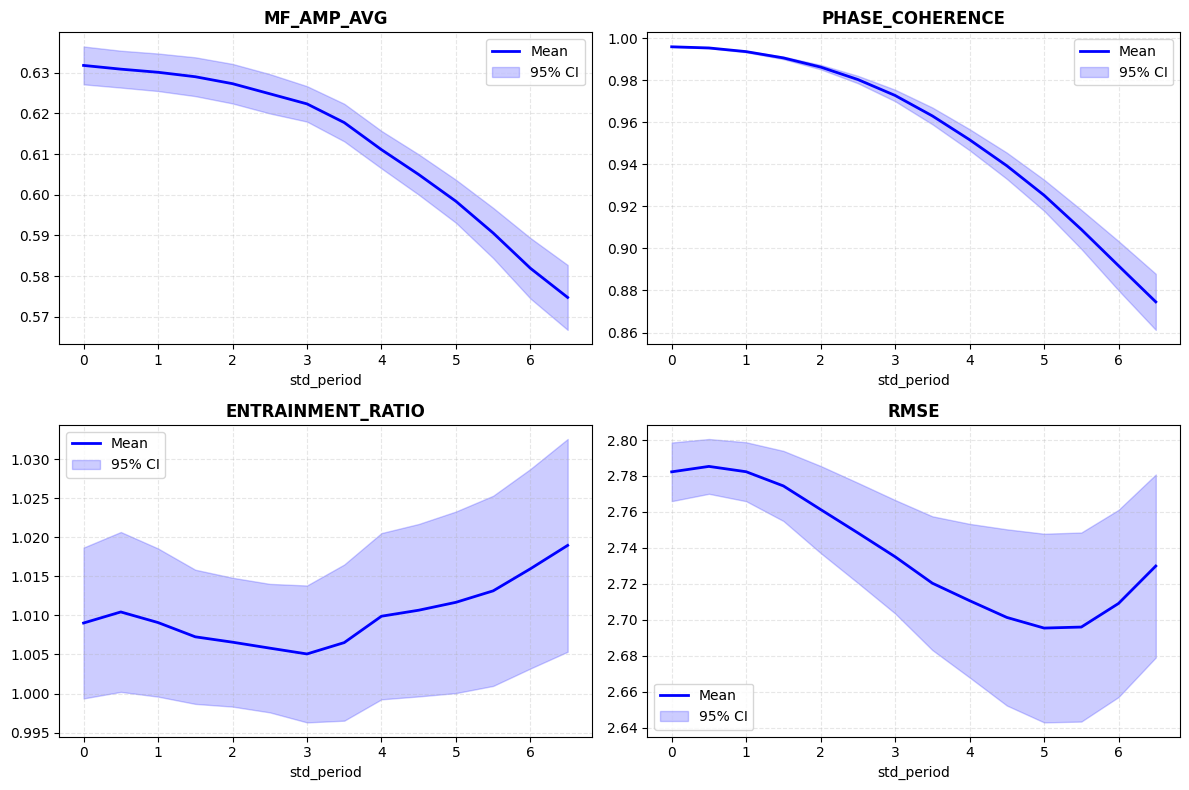

In [14]:
payload = run_1D_ensemble({**base_config, 'W_mu': 0.05},
                          sweep_param = 'std_period',
                          sweep_range = np.arange(0, 7.0, 0.5),
                          n_sample = 10,
                          master_seed = 42
                          )
plotting_1D_ensemble(payload, mode='standard');

========= CONFIGURATION =========
{'N': 100,
 'D': 10,
 'lam': 0.1,
 'gamma': 0.0,
 'mean_period': 23.5,
 'W_prob': 0.2,
 'W_mu': 0.05,
 'W_std': 0,
 'sweep': True,
 'std_phase_noise': 0.05,
 'std_m_noise': 0.0,
 'dt': 0.1,
 'fastmath': False}
std_period: (0.000, 7.000, 0.5)
sample size: 10



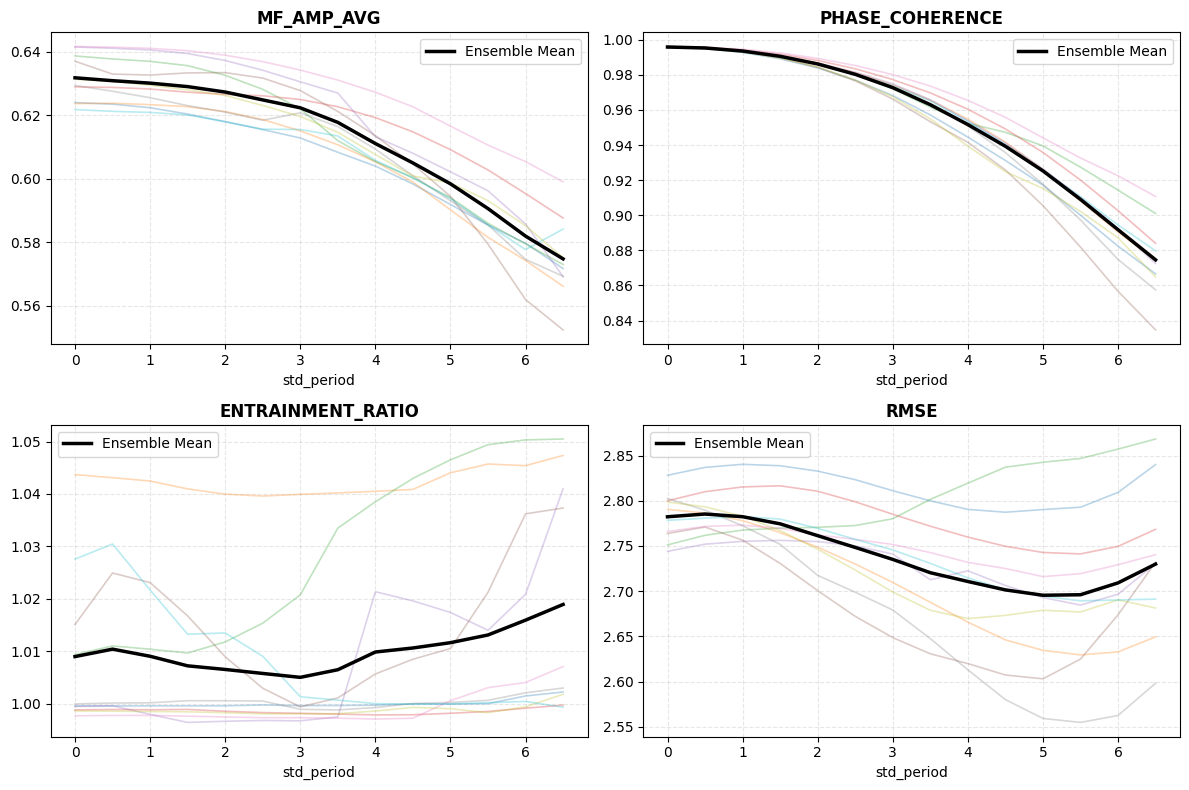

In [24]:
plotting_1D_ensemble(payload, mode='overlay', n_overlay_samples=10);

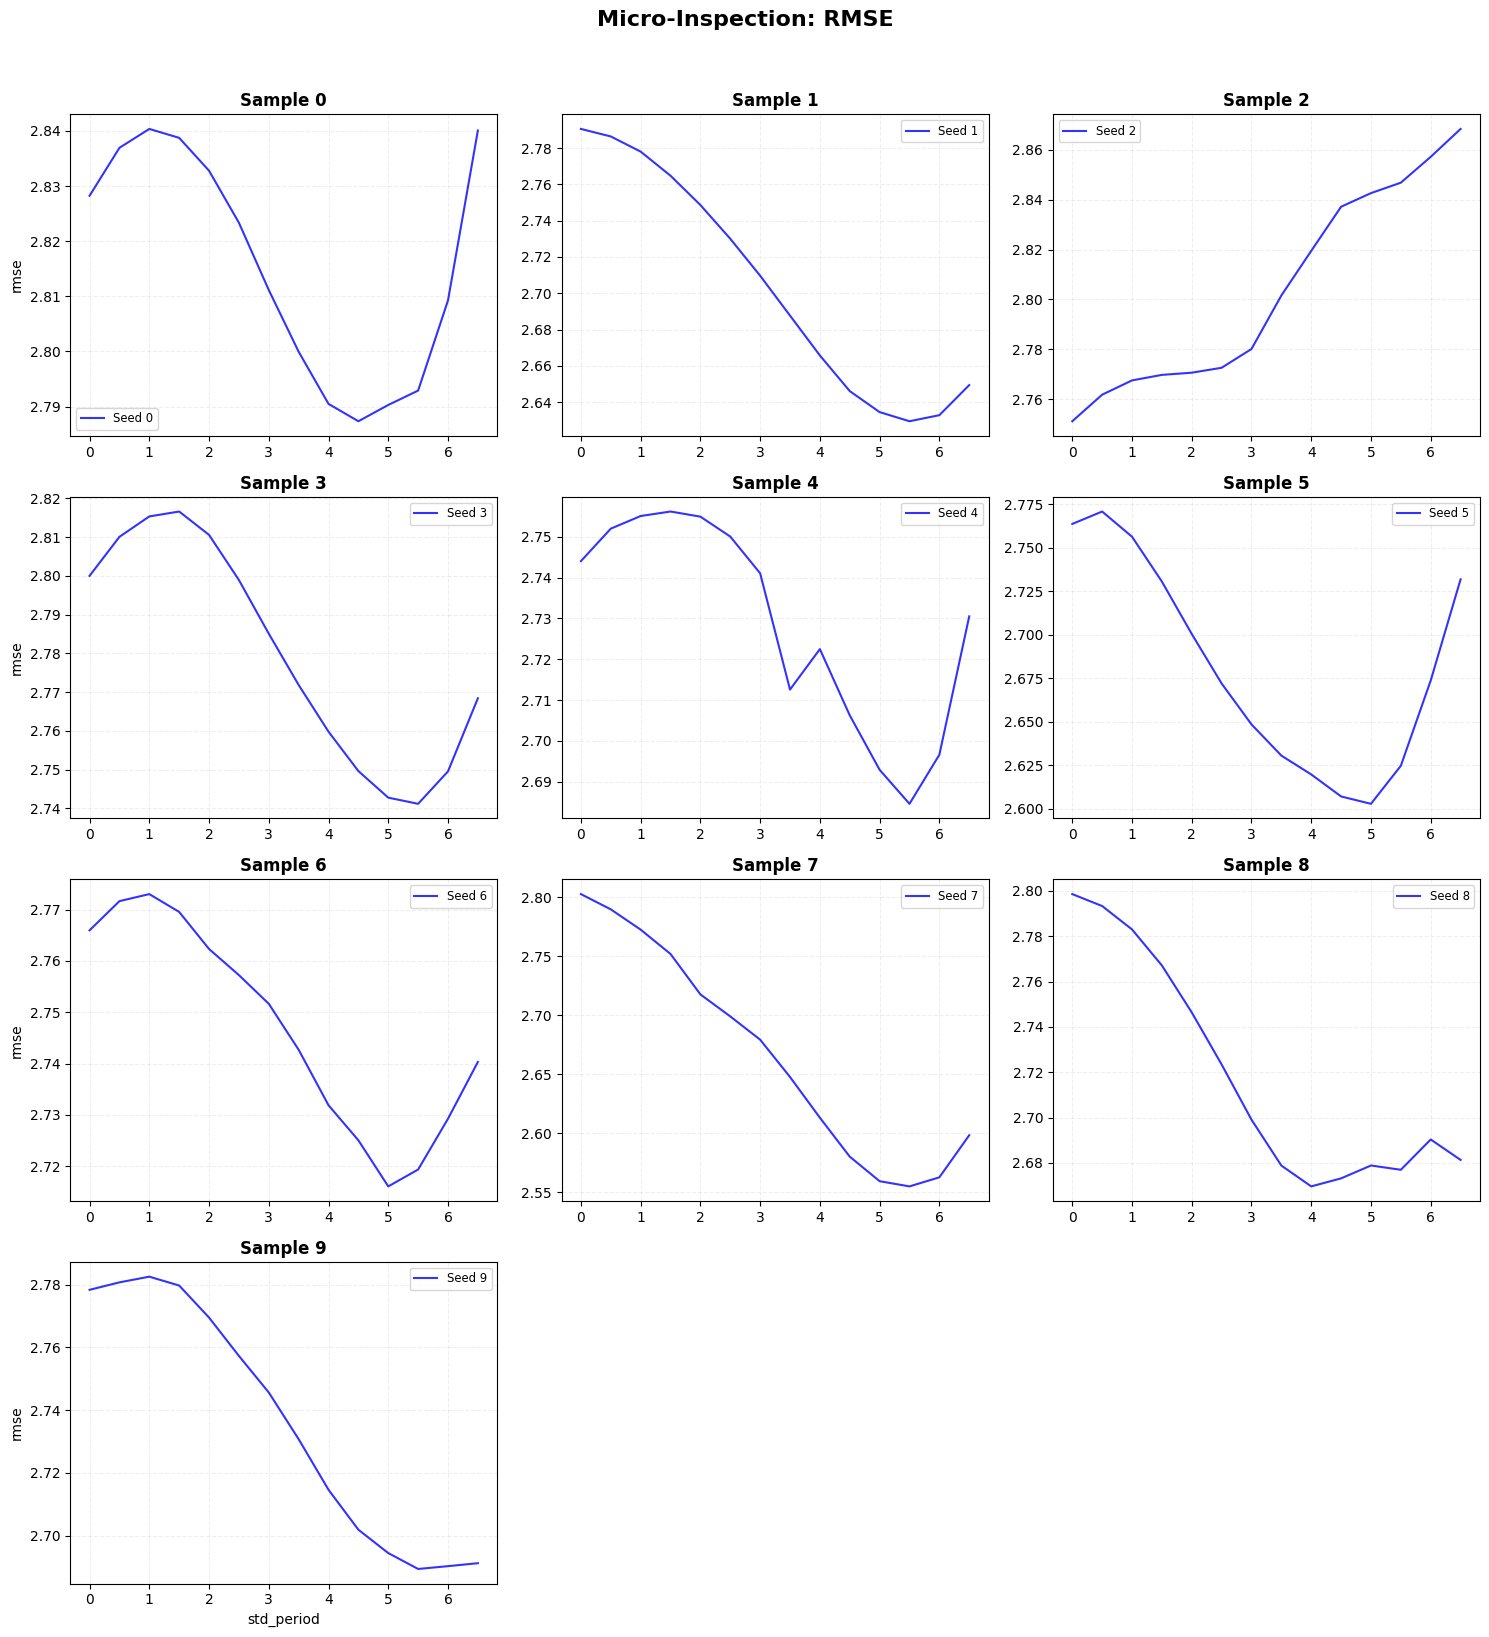

In [19]:
plot_inspection_grid(payload, target_metric='rmse');

 Simulating Sample 7 across 14 values of std_period...


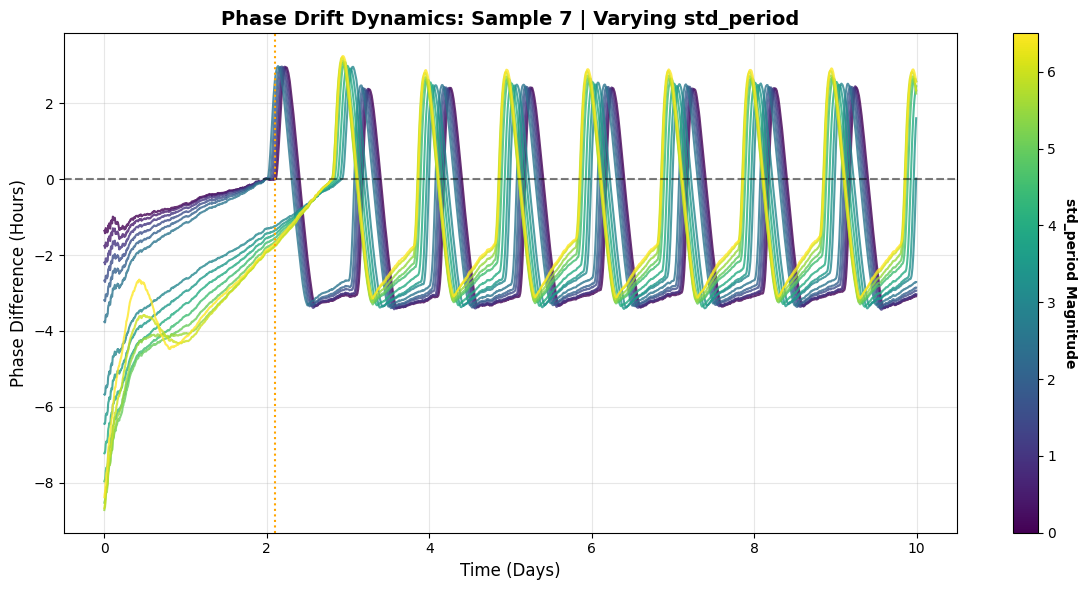

In [23]:
# Pass an array of specific noise values to stack them
plot_phase_walk(base_config, 
                      sweep_param='std_period', 
                      target_values=np.arange(0, 7,0.5), 
                      sample_id=7);

 Simulating Sample 7 across 1 values of std_period...


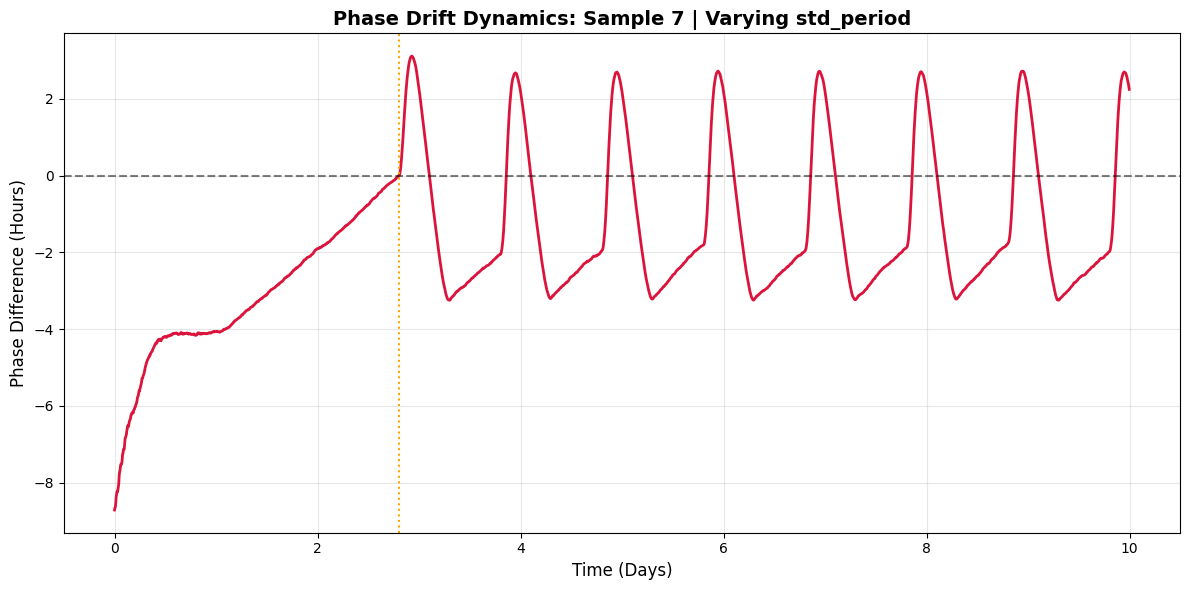

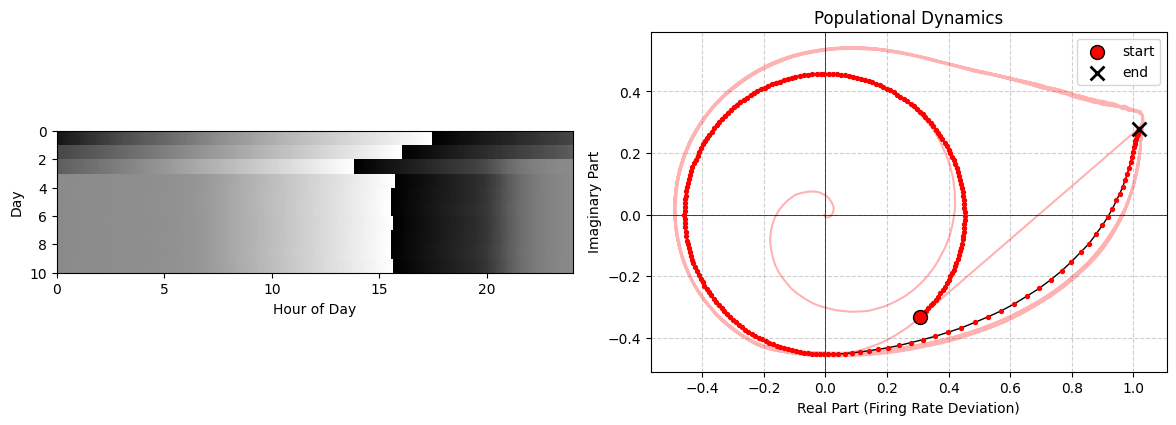

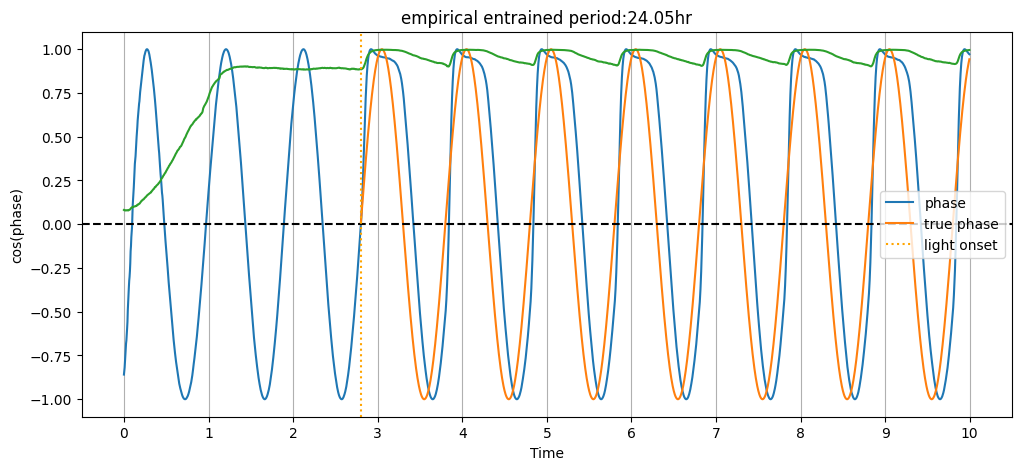

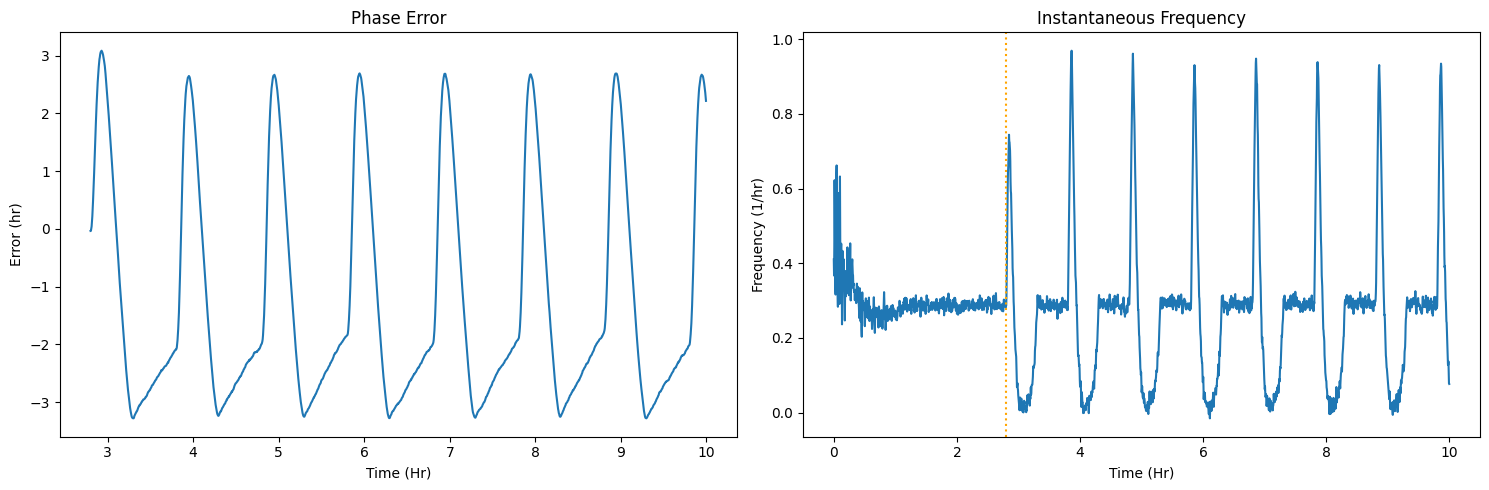

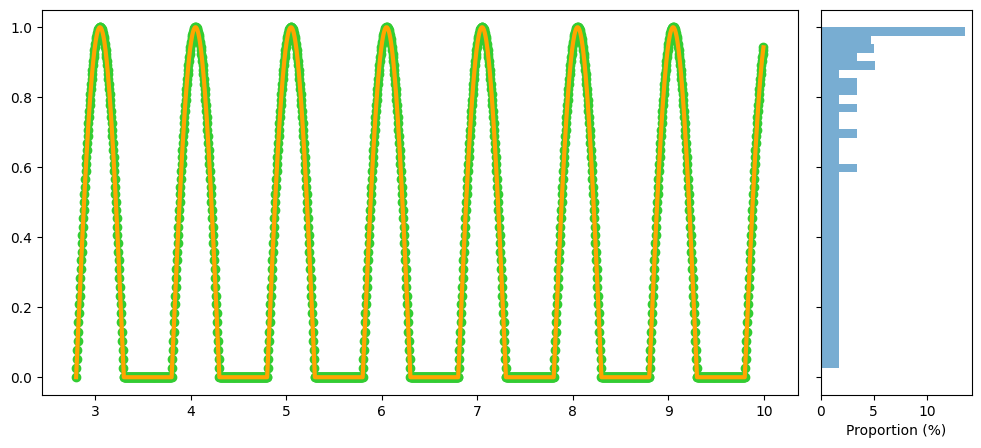

In [26]:
plot_phase_walk(base_config,
                sweep_param = 'std_period', 
                target_values = [5.5], 
                sample_id = 7,
                focus_day = 3,
                master_seed = 42);

### 2D Sweep

In [ ]:
run_2D_ensemble(
        base_config,
        sweep_param_1: 'std_m_noise',
        sweep_range_1: np.arange(0, 10.5, 0.5),
        sweep_param_2: 'std_period',
        sweep_range_2: np.arange(0, 5.5, 0.5),
        n_sample: int = 10,
        master_seed: int = 42
        )       

SyntaxError: '(' was never closed (4139706170.py, line 1)